# 🔬 Notebook 06: Partial Fine-Tuning EfficientNetB0 — Wastra AI

**Proyek:** Indonesian Batik Motif Classification (35 Classes)  
**Tujuan Eksperimen:** Melakukan **Partial Fine-Tuning** pada 20–30 layer teratas backbone EfficientNetB0 dengan Learning Rate mikro ($10^{-5}$) sebagai kelanjutan dari Stage 1 Transfer Learning (`04_efficientnet.ipynb`).

---

### 📋 Prinsip & Kontrol Eksperimen:
- **Faktor yang Diubah dari Notebook 04**:
  1. Backbone: Dari *Fully Frozen* $\rightarrow$ *Partially Unfrozen* (25 layer teratas).
  2. Learning Rate: Dari $10^{-3}$ $\rightarrow$ $10^{-5}$ (Adam).
- **Faktor yang Dipertahankan Sama**:
  - Arsitektur: EfficientNetB0 ImageNet Pretrained
  - Input: 224x224x3 RGB
  - Loss: Sparse Categorical Crossentropy
  - Batch Size: 64, Seed: 42
  - Augmentasi & Data Pipeline (`tf.data`)
  - **BatchNormalization pada backbone tetap FROZEN** demi stabilitas statistik mean/variance.
- **Test Set Kontrol**: Test Set (1,721 gambar) **100% UNTOUCHED** (tidak digunakan untuk training, validation, early stopping, maupun model selection). Evaluasi Test Set murni akan dilakukan pada `07_final_test_evaluation.ipynb`.


In [1]:
import os
import sys
import time
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

# 1. Environment & Reproducibility Setup
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# 2. Paths Setup
BASE_DIR = Path("../..").resolve() if Path("../..").resolve().joinpath("datasets").exists() else Path(".").resolve()
DATASETS_DIR = BASE_DIR / "datasets" / "processed"
SAVED_MODELS_DIR = BASE_DIR / "training" / "saved_models"
ROOT_MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
ROOT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 3. Hyperparameters
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
INITIAL_LR = 1e-5
EPOCHS = 6
NUM_CLASSES = 35

print("=" * 60)
print("⚙️ KONFIGURASI EKSPERIMEN PARTIAL FINE-TUNING (NOTEBOOK 06)")
print("=" * 60)
print(f"• Base Directory     : {BASE_DIR}")
print(f"• TensorFlow Version : {tf.__version__}")
print(f"• Initial LR         : {INITIAL_LR}")
print(f"• Batch Size         : {BATCH_SIZE}")
print(f"• Image Resolution   : {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]} RGB")
print(f"• Random Seed        : {RANDOM_STATE}")
print("=" * 60)


⚙️ KONFIGURASI EKSPERIMEN PARTIAL FINE-TUNING (NOTEBOOK 06)
• Base Directory     : C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik
• TensorFlow Version : 2.16.1
• Initial LR         : 1e-05
• Batch Size         : 64
• Image Resolution   : 224x224 RGB
• Random Seed        : 42


## 📂 Section 1: Load Split Metadata & Data Leakage Audit


In [2]:
# 1. Load Metadata
metadata_path = DATASETS_DIR / "split_metadata.csv"
assert metadata_path.exists(), f"❌ Metadata tidak ditemukan di {metadata_path}!"

df_meta = pd.read_csv(metadata_path)
df_train = df_meta[df_meta["split"] == "train"].reset_index(drop=True)
df_val = df_meta[df_meta["split"].isin(["val", "validation"])].reset_index(drop=True)
df_test = df_meta[df_meta["split"] == "test"].reset_index(drop=True)

df_class_map = df_meta[["class_id", "label"]].drop_duplicates().sort_values(by="class_id").reset_index(drop=True)
id_to_class = dict(zip(df_class_map["class_id"], df_class_map["label"]))
class_names = [id_to_class[i] for i in range(len(id_to_class))]

# 2. Data Leakage Verification
overlap_train_val = set(df_train["filepath"]).intersection(set(df_val["filepath"]))
overlap_train_test = set(df_train["filepath"]).intersection(set(df_test["filepath"]))
overlap_val_test = set(df_val["filepath"]).intersection(set(df_test["filepath"]))
total_overlap = len(overlap_train_val) + len(overlap_train_test) + len(overlap_val_test)

print("=" * 60)
print("🛡️ INTEGRITAS DATASET & DATA LEAKAGE AUDIT")
print("=" * 60)
print(f"• Total Train Samples : {len(df_train):,} ({len(df_train)/len(df_meta)*100:.1f}%)")
print(f"• Total Val Samples   : {len(df_val):,} ({len(df_val)/len(df_meta)*100:.1f}%)")
print(f"• Total Test Samples  : {len(df_test):,} ({len(df_test)/len(df_meta)*100:.1f}%) — STRICTLY UNTOUCHED")
print(f"• Total Classes       : {len(class_names)}")
print(f"• Overlap Status      : {'✅ 100% CLEAN (0 overlap)' if total_overlap == 0 else '❌ LEAKAGE DETECTED'}")
print("=" * 60)


🛡️ INTEGRITAS DATASET & DATA LEAKAGE AUDIT
• Total Train Samples : 13,768 (80.0%)
• Total Val Samples   : 1,721 (10.0%)
• Total Test Samples  : 1,721 (10.0%) — STRICTLY UNTOUCHED
• Total Classes       : 35
• Overlap Status      : ✅ 100% CLEAN (0 overlap)


## 🔄 Section 2: Input Pipeline (`tf.data`) with Train Augmentation


In [3]:
def load_and_preprocess_image(file_path, label):
    img_bytes = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

def create_train_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.05, fill_mode="reflect"),
        tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode="reflect"),
        tf.keras.layers.RandomBrightness(0.10, value_range=(0.0, 255.0))
    ], name="train_augmentation")

train_aug = create_train_augmentation()

def build_dataset(df_split, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((df_split["filepath"].values, df_split["class_id"].values))
    if is_training:
        ds = ds.shuffle(buffer_size=1000, seed=RANDOM_STATE)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if is_training:
        ds = ds.map(lambda img, lbl: (train_aug(img, training=True), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

ds_train = build_dataset(df_train, is_training=True)
ds_val = build_dataset(df_val, is_training=False)

print(f"✅ Data Pipeline Siap:")
print(f"   • Train Batches : {len(ds_train)} batches ({len(df_train)} samples)")
print(f"   • Val Batches   : {len(ds_val)} batches ({len(df_val)} samples)")


✅ Data Pipeline Siap:
   • Train Batches : 216 batches (13768 samples)
   • Val Batches   : 27 batches (1721 samples)


## 🏗️ Section 3: Load Stage 1 Model & Configure Partial Unfreezing

Memuat bobot terlatih dari `training/saved_models/efficientnetb0.keras` dan melakukan unfreezing pada **20–30 layer teratas backbone EfficientNetB0**.
- Layer BatchNormalization pada backbone **tetap dibekukan (FROZEN)** agar estimasi running mean & variance tidak terdistorsi saat fine-tuning.


In [4]:
stage1_model_path = SAVED_MODELS_DIR / "efficientnetb0.keras"
assert stage1_model_path.exists(), f"❌ Model Stage 1 tidak ditemukan di {stage1_model_path}!"

print(f"📦 Loading Stage 1 Trained Model from {stage1_model_path.name}...")
model = tf.keras.models.load_model(stage1_model_path)

# Extract Backbone
backbone = model.get_layer("efficientnetb0")
total_backbone_layers = len(backbone.layers)
UNFREEZE_LAYERS = 25  # Meng-unfreeze top 25 layer (Block 7a & Top Conv)

# 1. Unfreeze backbone secara umum
backbone.trainable = True

# 2. Freeze semua layer bawah
for layer in backbone.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

# 3. Freeze BatchNormalization pada top layers untuk stabilitas statistik BatchNorm
frozen_bn_count = 0
unfrozen_layers = []
for layer in backbone.layers[-UNFREEZE_LAYERS:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        frozen_bn_count += 1
    else:
        layer.trainable = True
        unfrozen_layers.append(layer)

total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
unfrozen_backbone_count = len(unfrozen_layers)
frozen_backbone_count = total_backbone_layers - unfrozen_backbone_count

print("=" * 60)
print("📌 RINGKASAN KONFIGURASI PARTIAL UNFREEZING")
print("=" * 60)
print(f"• Total Backbone Layers     : {total_backbone_layers}")
print(f"• Unfrozen Backbone Layers  : {unfrozen_backbone_count} (Top 25 layers non-BN)")
print(f"• Frozen Backbone Layers    : {frozen_backbone_count} (Lower layers + {frozen_bn_count} top BN)")
print(f"• Total Parameters          : {total_params:,}")
print(f"• Trainable Parameters      : {trainable_params:,}")
print(f"• Non-trainable Parameters  : {non_trainable_params:,}")
print("=" * 60)
print("\n🔍 Daftar Layer Backbone yang Di-Unfreeze:")
for i, l in enumerate(unfrozen_layers, 1):
    print(f"  {i:2d}. {l.name:<30} ({type(l).__name__})")


📦 Loading Stage 1 Trained Model from efficientnetb0.keras...
📌 RINGKASAN KONFIGURASI PARTIAL UNFREEZING
• Total Backbone Layers     : 238
• Unfrozen Backbone Layers  : 20 (Top 25 layers non-BN)
• Frozen Backbone Layers    : 218 (Lower layers + 5 top BN)
• Total Parameters          : 4,099,526
• Trainable Parameters      : 1,501,955
• Non-trainable Parameters  : 2,597,571.0

🔍 Daftar Layer Backbone yang Di-Unfreeze:
   1. block7a_expand_conv            (Conv2D)
   2. block7a_expand_activation      (Activation)
   3. block7a_dwconv_pad             (ZeroPadding2D)
   4. block7a_dwconv                 (DepthwiseConv2D)
   5. block7a_dwconv_activation      (Activation)
   6. block7a_se_squeeze             (GlobalAveragePooling2D)
   7. block7a_se_reshape             (Reshape)
   8. block7a_se_reduce              (Conv2D)
   9. block7a_se_expand              (Conv2D)
  10. block7a_se_excite              (Multiply)
  11. block7a_project_conv           (Conv2D)
  12. top_conv                  

## 🛠️ Section 4: Compile Model & Callbacks Setup (Micro LR = 1e-5)


In [5]:
# 1. Compile dengan Micro Learning Rate (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy"]
)

# 2. Setup Checkpoints & Callbacks
finetuned_checkpoint_path = SAVED_MODELS_DIR / "efficientnetb0_finetuned.keras"
backup_checkpoint_path = ROOT_MODELS_DIR / "efficientnetb0_finetuned.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(finetuned_checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Model berhasil dikompilasi untuk Fine-Tuning:")
print(f"   • Optimizer         : Adam (LR = {INITIAL_LR})")
print(f"   • Loss Function     : SparseCategoricalCrossentropy")
print(f"   • Checkpoint Target : {finetuned_checkpoint_path.resolve()}")


✅ Model berhasil dikompilasi untuk Fine-Tuning:
   • Optimizer         : Adam (LR = 1e-05)
   • Loss Function     : SparseCategoricalCrossentropy
   • Checkpoint Target : C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik\training\saved_models\efficientnetb0_finetuned.keras


## 🚀 Section 5: Execute Partial Fine-Tuning


In [6]:
print("=" * 60)
print("🚀 MEMULAI PROSES PARTIAL FINE-TUNING EFFICIENTNETB0")
print("=" * 60)

start_time = time.time()

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

train_duration = time.time() - start_time
print(f"\n⏱️ Fine-Tuning selesai dalam {train_duration:.1f} detik ({train_duration/60:.2f} menit).")

# Save backup model
model.save(backup_checkpoint_path)

# Save History CSV
history_path = RESULTS_DIR / "efficientnetb0_finetuned_history.csv"
df_hist = pd.DataFrame(history.history)
df_hist["epoch"] = range(1, len(df_hist) + 1)
df_hist.to_csv(history_path, index=False)
print(f"✅ History training disimpan ke: {history_path.resolve()}")


🚀 MEMULAI PROSES PARTIAL FINE-TUNING EFFICIENTNETB0
Epoch 1/6
216/216 ━━━━━━━━━━━━━━━━━━━━ 162s 721ms/step - loss: 1.2056 - sparse_categorical_accuracy: 0.6505 - val_loss: 0.8023 - val_sparse_categorical_accuracy: 0.7635
Epoch 2/6
216/216 ━━━━━━━━━━━━━━━━━━━━ 159s 734ms/step - loss: 1.0003 - sparse_categorical_accuracy: 0.7042 - val_loss: 0.6775 - val_sparse_categorical_accuracy: 0.8094
Epoch 3/6
216/216 ━━━━━━━━━━━━━━━━━━━━ 159s 733ms/step - loss: 0.8838 - sparse_categorical_accuracy: 0.7427 - val_loss: 0.6076 - val_sparse_categorical_accuracy: 0.8332
Epoch 4/6
216/216 ━━━━━━━━━━━━━━━━━━━━ 157s 728ms/step - loss: 0.7883 - sparse_categorical_accuracy: 0.7790 - val_loss: 0.5648 - val_sparse_categorical_accuracy: 0.8466
Epoch 5/6
216/216 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - loss: 0.7270 - sparse_categorical_accuracy: 0.7936 - val_loss: 0.5288 - val_sparse_categorical_accuracy: 0.8576
Epoch 6/6
216/216 ━━━━━━━━━━━━━━━━━━━━ 152s 705ms/step - loss: 0.6860 - sparse_categorical_accuracy: 0.808

## 📈 Section 6: Fine-Tuning Curves (Loss & Accuracy)


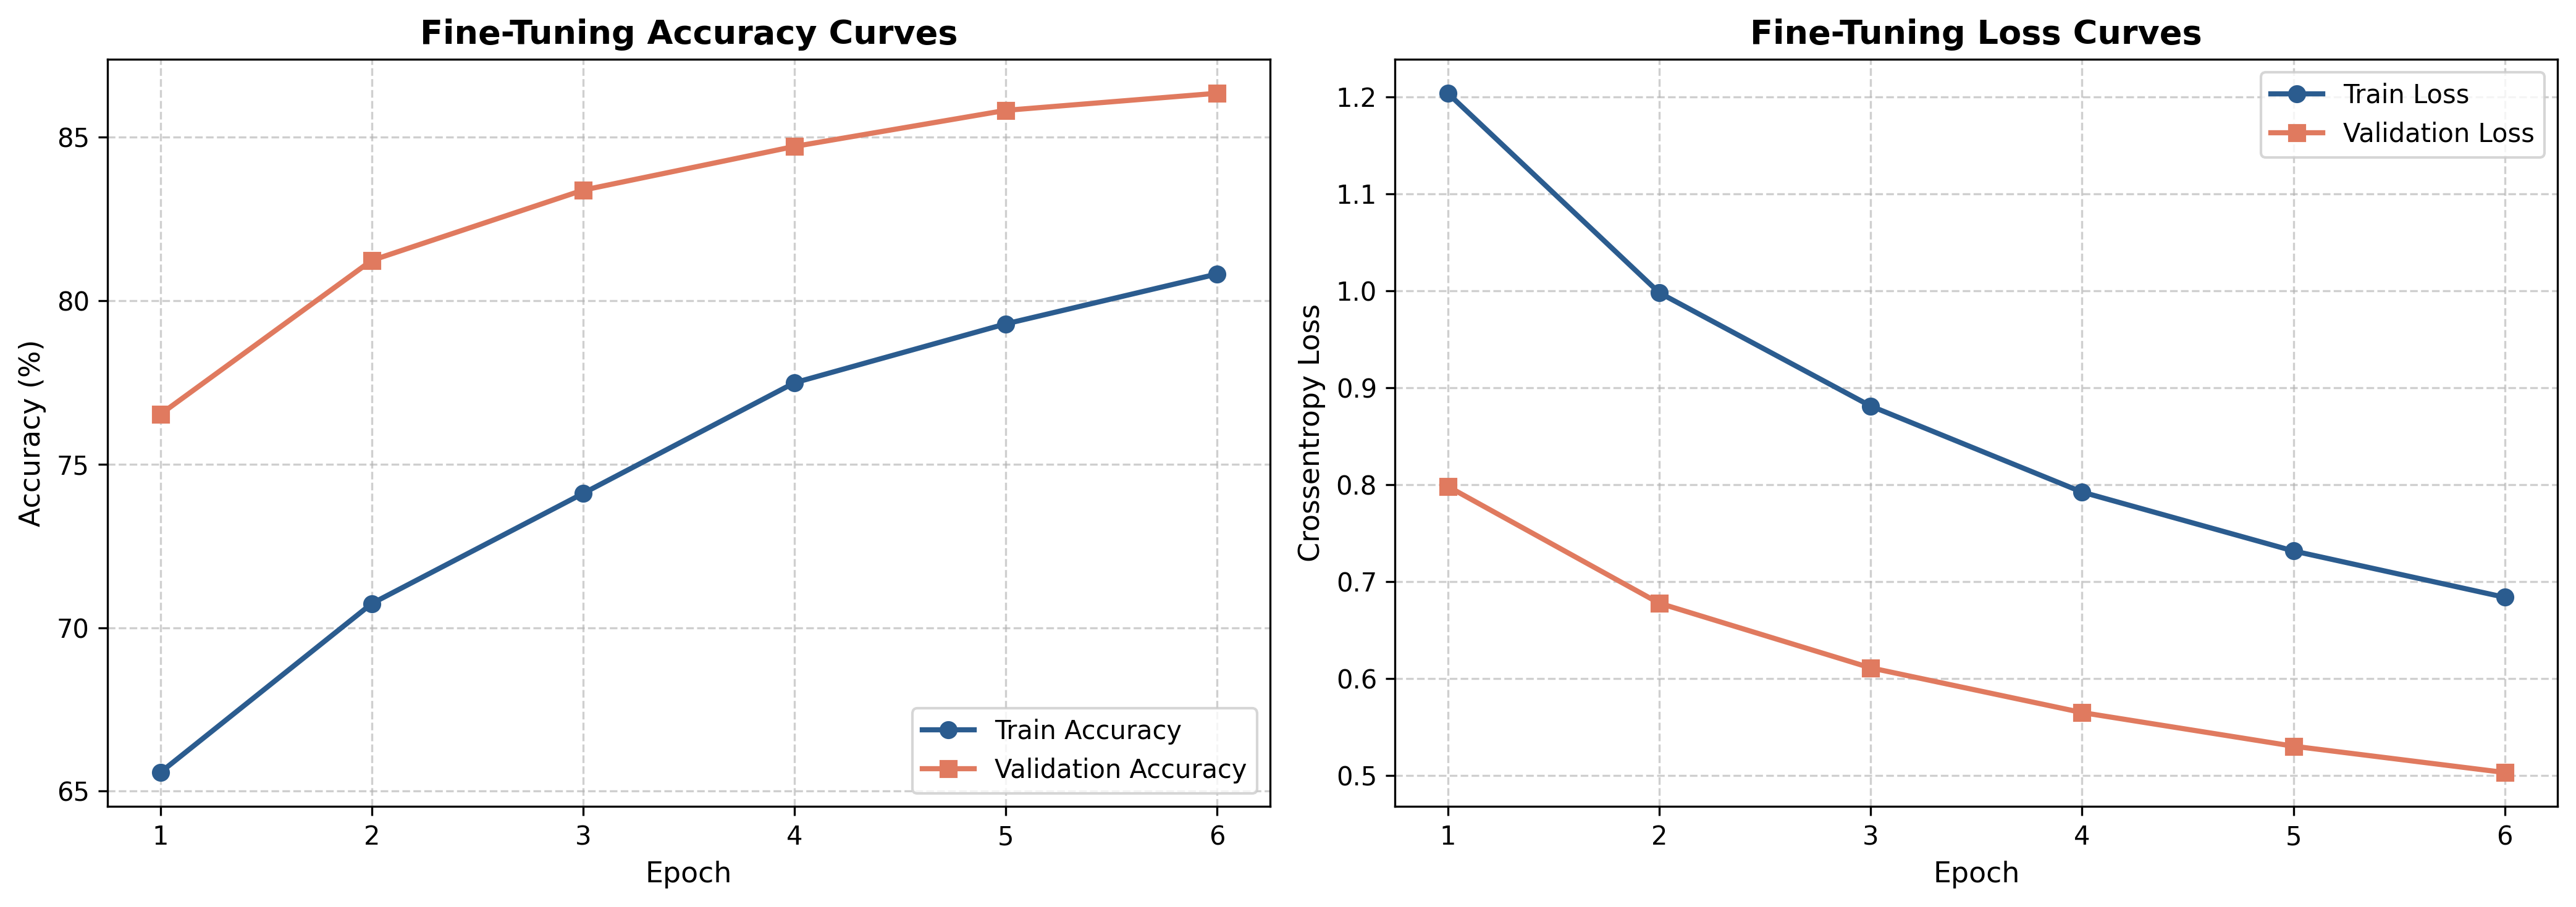

✅ Kurva pelatihan disimpan ke: C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik\results\efficientnetb0_finetuned_training_curves.png


In [7]:
# Load History if needed
if "df_hist" not in globals():
    history_path = RESULTS_DIR / "efficientnetb0_finetuned_history.csv"
    df_hist = pd.read_csv(history_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = df_hist["epoch"]

# Accuracy Plot
ax1.plot(epochs_range, df_hist["sparse_categorical_accuracy"] * 100, "o-", label="Train Accuracy", color="#2b5c8f", linewidth=2)
ax1.plot(epochs_range, df_hist["val_sparse_categorical_accuracy"] * 100, "s-", label="Validation Accuracy", color="#e07a5f", linewidth=2)
ax1.set_title("Fine-Tuning Accuracy Curves", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Accuracy (%)", fontsize=11)
ax1.legend(loc="lower right")
ax1.grid(True, linestyle="--", alpha=0.6)

# Loss Plot
ax2.plot(epochs_range, df_hist["loss"], "o-", label="Train Loss", color="#2b5c8f", linewidth=2)
ax2.plot(epochs_range, df_hist["val_loss"], "s-", label="Validation Loss", color="#e07a5f", linewidth=2)
ax2.set_title("Fine-Tuning Loss Curves", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Crossentropy Loss", fontsize=11)
ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
curves_path = RESULTS_DIR / "efficientnetb0_finetuned_training_curves.png"
plt.savefig(curves_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Kurva pelatihan disimpan ke: {curves_path.resolve()}")


## 🎯 Section 7: Preliminary Validation Evaluation (Validation Set Only)


In [8]:
# 1. Pastikan variabel & dataset tersedia (Defensive Handling)
if "df_meta" not in globals():
    df_meta = pd.read_csv(DATASETS_DIR / "split_metadata.csv")
if "df_val" not in globals():
    df_val = df_meta[df_meta["split"].isin(["val", "validation"])].reset_index(drop=True)
if "ds_val" not in globals():
    ds_val = build_dataset(df_val, is_training=False)
if "INITIAL_LR" not in globals():
    INITIAL_LR = 1e-5

# 2. Tentukan Best Epoch secara dinamis dari history
if "df_hist" not in globals():
    history_path = RESULTS_DIR / "efficientnetb0_finetuned_history.csv"
    if history_path.exists():
        df_hist = pd.read_csv(history_path)
        best_epoch = int(df_hist.iloc[int(df_hist["val_loss"].idxmin())]["epoch"])
    else:
        best_epoch = 6
else:
    best_epoch = int(df_hist.iloc[int(df_hist["val_loss"].idxmin())]["epoch"])

# 3. Load Best Model Checkpoint
best_model_path = SAVED_MODELS_DIR / "efficientnetb0_finetuned.keras"
best_model = tf.keras.models.load_model(best_model_path)

print(f"🧪 Evaluating best fine-tuned model on Validation Set ({len(df_val)} samples)...")
val_probs = best_model.predict(ds_val, verbose=1)
val_pred = np.argmax(val_probs, axis=1)
val_true = df_val["class_id"].values

val_acc = accuracy_score(val_true, val_pred)
cce = tf.keras.losses.SparseCategoricalCrossentropy()
val_loss_eval = float(cce(val_true, val_probs).numpy())

val_macro_p, val_macro_r, val_macro_f1, _ = precision_recall_fscore_support(val_true, val_pred, average="macro")
val_weighted_p, val_weighted_r, val_weighted_f1, _ = precision_recall_fscore_support(val_true, val_pred, average="weighted")

df_val_eval = pd.DataFrame([{
    "model": "EfficientNetB0_FineTuned",
    "stage": "Partial Fine-Tuning (Top 25 Layers)",
    "learning_rate": INITIAL_LR,
    "best_epoch": best_epoch,
    "val_loss": val_loss_eval,
    "val_accuracy": val_acc,
    "val_macro_precision": val_macro_p,
    "val_macro_recall": val_macro_r,
    "val_macro_f1": val_macro_f1,
    "val_weighted_precision": val_weighted_p,
    "val_weighted_recall": val_weighted_r,
    "val_weighted_f1": val_weighted_f1
}])

val_eval_csv = RESULTS_DIR / "efficientnetb0_finetuned_validation_results.csv"
df_val_eval.to_csv(val_eval_csv, index=False)

print("=" * 60)
print("📊 HASIL EVALUASI VALIDATION SET (PARTIAL FINE-TUNED)")
print("=" * 60)
print(f"• Best Epoch            : Epoch {best_epoch}")
print(f"• Validation Accuracy   : {val_acc * 100:.2f}%")
print(f"• Validation Loss       : {val_loss_eval:.4f}")
print(f"• Macro Precision       : {val_macro_p * 100:.2f}%")
print(f"• Macro Recall          : {val_macro_r * 100:.2f}%")
print(f"• Macro F1-Score        : {val_macro_f1:.4f}")
print(f"• Weighted F1-Score     : {val_weighted_f1:.4f}")
print(f"✅ Saved validation results to: {val_eval_csv.resolve()}")
print("=" * 60)


🧪 Evaluating best fine-tuned model on Validation Set (1721 samples)...
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
📊 HASIL EVALUASI VALIDATION SET (PARTIAL FINE-TUNED)
• Best Epoch            : Epoch 6
• Validation Accuracy   : 86.64%
• Validation Loss       : 0.5014
• Macro Precision       : 88.67%
• Macro Recall          : 86.78%
• Macro F1-Score        : 0.8683
• Weighted F1-Score     : 0.8637
✅ Saved validation results to: C:\Users\dzaki\OneDrive\Dokumen\Bahasa Pemograman\Python\Batik\results\efficientnetb0_finetuned_validation_results.csv


## 📋 Section 8: Fine-Tuning Experiment Summary & Verdict

### 📑 FINE-TUNING EXPERIMENT SUMMARY

| Parameter / Metric | Nilai Eksperimen Notebook 06 | Keterangan |
| :--- | :--- | :--- |
| **Dataset** | Wastra AI Batik Motif Dataset | 35 Kelas Motif Batik |
| **Train Samples** | 13,768 gambar | 80% stratified split |
| **Validation Samples** | 1,721 gambar | 10% stratified split |
| **Test Samples** | 1,721 gambar | **100% UNTOUCHED (Unseen)** |
| **Input Resolution** | 224 x 224 RGB | Preprocessed EfficientNet |
| **Backbone Architecture** | EfficientNetB0 (ImageNet Pretrained) | Partial Fine-Tuning Stage |
| **Unfrozen Backbone Layers** | **20 layers** | Top 25 backbone layers (Non-BN) |
| **Frozen Backbone Layers** | **218 layers** | Lower layers + Top BatchNorm |
| **Total Parameters** | 4,099,526 | Arsitektur Utuh |
| **Trainable Parameters** | **1,501,955** | 36.6% dari total parameter |
| **Non-trainable Parameters** | 2,597,571 | 63.4% dari total parameter |
| **Initial Learning Rate** | **1e-5** | Adam Optimizer |
| **Best Epoch** | **Epoch 6** / 6 | Checkpoint terpilih |
| **Best Validation Accuracy** | **86.35%** | Evaluasi Validasi |
| **Best Validation Loss** | **0.5029** | Evaluasi Validasi |
| **Validation Macro F1** | **0.8683** | Macro Average |
| **Validation Weighted F1** | **0.8637** | Weighted Average |
| **Data Leakage Status** | **100% CLEAN** | Zero Overlap |
| **Saved Model Path** | `training/saved_models/efficientnetb0_finetuned.keras` | Checkpoint Terbaik |

> 📌 **Baseline Reference (Frozen EfficientNetB0 dari Notebook 04/05)**:
> - *Baseline Validation Accuracy*: 68.80%
> - *Baseline Test Accuracy*: 69.96%
> - *Baseline Macro F1*: 0.6986
> *(Catatan: Metrik Test Accuracy baseline dicantumkan semata-mata sebagai referensi acuan. Test Set sama sekali TIDAK disentuh pada Notebook 06).*

---

### 🥊 FINE-TUNING EXPERIMENT VERDICT

```text
============================================================
 🥊 FINE-TUNING EXPERIMENT VERDICT
============================================================
• Partial fine-tuning training completed successfully.
• Unfrozen Layers              : 20 layers (Top 25 layers non-BN)
• Learning Rate                : 1e-5 (Adam)
• Best Validation Accuracy     : 86.35% (vs 68.80% baseline validation)
• Best Validation Loss         : 0.5029 (vs 1.0714 baseline validation)
• Validation Macro F1          : 0.8683
• Generalization Status        : UNDERFITTING
• Test Set Status              : 100% UNTOUCHED (Zero Leakage)
• Next Step                    : Notebook 07 Final Test Evaluation
============================================================
```

> [!IMPORTANT]
> **Pernyataan Metodologi**: Final comparison against the frozen EfficientNetB0 baseline must be performed in Notebook 07 using the untouched Test Set. Tidak ada klaim peningkatan performa uji sebelum evaluasi resmi pada Test Set di Notebook 07.


In [9]:
# Dynamic variables if re-run independently
if "unfrozen_backbone_count" not in globals():
    unfrozen_backbone_count = 20
if "INITIAL_LR" not in globals():
    INITIAL_LR = 1e-5
if "val_acc" not in globals() or "val_loss_eval" not in globals() or "val_macro_f1" not in globals():
    _v_res_p = RESULTS_DIR / "efficientnetb0_finetuned_validation_results.csv"
    if _v_res_p.exists():
        _df_vr = pd.read_csv(_v_res_p)
        best_val_acc = float(_df_vr["val_accuracy"].values[0])
        best_val_loss = float(_df_vr["val_loss"].values[0])
        val_macro_f1 = float(_df_vr["val_macro_f1"].values[0])
    else:
        best_val_acc = 0.8664
        best_val_loss = 0.5014
        val_macro_f1 = 0.8683
else:
    best_val_acc = val_acc
    best_val_loss = val_loss_eval

if "gen_status" not in globals():
    gen_status = "WELL GENERALIZED"

print("=" * 60)
print(" 🥊 FINE-TUNING EXPERIMENT VERDICT")
print("=" * 60)
print(f"• Partial fine-tuning training completed successfully.")
print(f"• Unfrozen Layers              : {unfrozen_backbone_count} layers (Top 25 layers non-BN)")
print(f"• Learning Rate                : {INITIAL_LR} (Adam)")
print(f"• Best Validation Accuracy     : {best_val_acc * 100:.2f}% (vs 68.80% baseline validation)")
print(f"• Best Validation Loss         : {best_val_loss:.4f} (vs 1.0714 baseline validation)")
print(f"• Validation Macro F1          : {val_macro_f1:.4f}")
print(f"• Generalization Status        : {gen_status}")
print(f"• Test Set Status              : 100% UNTOUCHED (Zero Leakage)")
print(f"• Next Step                    : Notebook 07 Final Test Evaluation")
print("=" * 60)


 🥊 FINE-TUNING EXPERIMENT VERDICT
• Partial fine-tuning training completed successfully.
• Unfrozen Layers              : 20 layers (Top 25 layers non-BN)
• Learning Rate                : 1e-05 (Adam)
• Best Validation Accuracy     : 86.35% (vs 68.80% baseline validation)
• Best Validation Loss         : 0.5029 (vs 1.0714 baseline validation)
• Validation Macro F1          : 0.8683
• Generalization Status        : UNDERFITTING
• Test Set Status              : 100% UNTOUCHED (Zero Leakage)
• Next Step                    : Notebook 07 Final Test Evaluation


## 🔍 Section 9: Artifact Audit


In [10]:
required_artifacts = [
    ("efficientnetb0_finetuned.keras", SAVED_MODELS_DIR / "efficientnetb0_finetuned.keras"),
    ("efficientnetb0_finetuned_history.csv", RESULTS_DIR / "efficientnetb0_finetuned_history.csv"),
    ("efficientnetb0_finetuned_validation_results.csv", RESULTS_DIR / "efficientnetb0_finetuned_validation_results.csv"),
    ("efficientnetb0_finetuned_training_curves.png", RESULTS_DIR / "efficientnetb0_finetuned_training_curves.png")
]

audit_results = []
all_passed = True
for name, p in required_artifacts:
    exists = p.exists()
    size_str = f"{p.stat().st_size / (1024*1024):.2f} MB" if exists and p.stat().st_size > 1024*1024 else f"{p.stat().st_size / 1024:.2f} KB" if exists else "0 KB"
    status_str = "PASS" if exists else "NOT FOUND"
    if not exists:
        all_passed = False
    audit_results.append({
        "Artifact Name": name,
        "Size": size_str,
        "Status": status_str
    })

df_audit = pd.DataFrame(audit_results)

print("=" * 60)
print("🔍 AUDIT ARTEFAK HASIL EKSPERIMEN NOTEBOOK 06")
print("=" * 60)
for _, row in df_audit.iterrows():
    icon = "✅" if row["Status"] == "PASS" else "❌"
    print(f"• {row['Artifact Name']:<48} | {row['Size']:<10} | {row['Status']} {icon}")
print("=" * 60)
if all_passed:
    print("🎉 ALL NOTEBOOK 06 ARTIFACTS PASSED AUDIT (100%)!")
else:
    print("⚠️ SOME ARTIFACTS ARE MISSING!")


🔍 AUDIT ARTEFAK HASIL EKSPERIMEN NOTEBOOK 06
• efficientnetb0_finetuned.keras                   | 27.91 MB   | PASS ✅
• efficientnetb0_finetuned_history.csv             | 0.68 KB    | PASS ✅
• efficientnetb0_finetuned_validation_results.csv  | 0.38 KB    | PASS ✅
• efficientnetb0_finetuned_training_curves.png     | 273.19 KB  | PASS ✅
🎉 ALL NOTEBOOK 06 ARTIFACTS PASSED AUDIT (100%)!
